In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pandas_datareader as web
#import scipy.optimize as opt
import csv
#from scipy.optimize import minimize
#from scipy.optimize import linprog
import math
#from scipy.optimize import LinearConstraint
from scipy.stats import norm

In [28]:
K = []
C = []
with open('ArbFree_calls_strikes.csv', mode='r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            C.append(float(row[0]))
            K.append(float(row[1]))
print(C)
print(K)

[168.4133399330829, 163.4321247614138, 158.45978514970272, 153.49349246032202, 148.53187565878937, 143.57429861477115, 138.62093449155566, 133.67207098355698, 128.72815461998383, 123.79002509759471, 118.85893384461724, 113.9367677749185, 109.02682618840166, 104.13153255629847, 99.25290369163748, 94.39175539840762, 89.54866100850388, 84.72702742614388, 79.93246092763576, 75.26860041513942, 70.55134378990911, 65.88444254069192, 61.281342050568284, 56.75053872993846, 52.30394091124656, 47.95635715932733, 43.7148578748703, 39.57395750832856, 35.52429900004181, 31.605693148493646, 27.93179539829821, 24.483950438107577, 21.247592604103957, 18.256463782472043, 15.497335972995323, 12.994055646567904, 10.801108920852343, 8.902841447774405, 7.270036515402826, 5.893511908013883, 4.791577893839746, 3.9119200479223646, 3.2894179573540323, 2.5723583673939014, 2.0936072095992992, 1.9131016894191835, 1.52496851961089, 1.4194296085227076, 1.3392615078134658, 1.1001492765838476]
[1103.9, 1108.9, 1113.9,

In [5]:
S = 1271.87
Kbar = 2000
N = len(K)

In [6]:
def Atilde(sigma,A,B,w,K):
    return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)

In [7]:
def Btilde(sigma,A,B,w,K):
    return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)

In [8]:
def findSigmaHat(A,B,w,K1,K2,V):
    my_eps = 1.0e-8
    def SigmaHat_obj(sigma):
        return Atilde(sigma,A,B,w,K1) + Btilde(sigma,A,B,w,K1)*(K2-w) - V
    low = my_eps
    high = 1.0
    while (SigmaHat_obj(high) > 0):
        high = 2.0*high
    while (high - low > my_eps):
        mid = 0.5 * (low + high)
        if (SigmaHat_obj(mid) >= 0):
            low = mid
        else:
            high = mid
    return 0.5 * (low + high)

In [9]:
def SigmaTilde(sigma,A,B,w,K1,K2,V):
    #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
    my_eps = 1.0e-8
    At = Atilde(sigma,A,B,w,K1)
    Bt = Btilde(sigma,A,B,w,K1)
    def SigmaTilde_obj(sigma_t):
        return 0.5*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) + 0.5*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t) - V
    low = my_eps
    high = 1
    while (SigmaTilde_obj(high) > 0):
        high = 2.0*high
    while (high - low > my_eps):
        mid = 0.5 * (low + high)
        if (SigmaTilde_obj(mid) >= 0):
            low = mid
        else:
            high = mid
    return 0.5 * (low + high)

In [10]:
def FindSigma(A,B,w,K1,K2,V,B1,sigma_h):
    #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
    my_eps = 1.0e-8
    def FindSigma_obj(sigma):
        sigma_t = SigmaTilde(sigma,A,B,w,K1,K2,V)
        At = Atilde(sigma,A,B,w,K1)
        Bt = Btilde(sigma,A,B,w,K1)
        return B1 - (0.5/sigma_t)*(At + sigma_t*Bt)*np.exp((K2-w)/sigma_t) + (0.5/sigma_t)*(At - sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
    low = sigma_h
    high = sigma_h+1
    while (FindSigma_obj(high) > 0):
        high = 2.0*high
    #print(high)
    while (high - low > my_eps):
        mid = 0.5 * (low + high)
        if (FindSigma_obj(mid) >= 0):
            low = mid
        else:
            high = mid
    return 0.5 * (low + high)

# Main algo

33
16.46360217899634
16.562359307453374
16.51298074322486
[0, 1103.9, 1108.9, 1113.9, 1118.9, 1123.9, 1128.9, 1133.9, 1138.9, 1143.9, 1148.9, 1153.9, 1158.9, 1163.9, 1168.9, 1173.9, 1178.9, 1183.9, 1188.9, 1193.9, 1198.8, 1203.8, 1208.8, 1213.8, 1218.8, 1223.8, 1228.8, 1233.8, 1238.8, 1243.8, 1248.8, 1253.8, 1258.8, 1263.8, 1268.8, 1271.87]


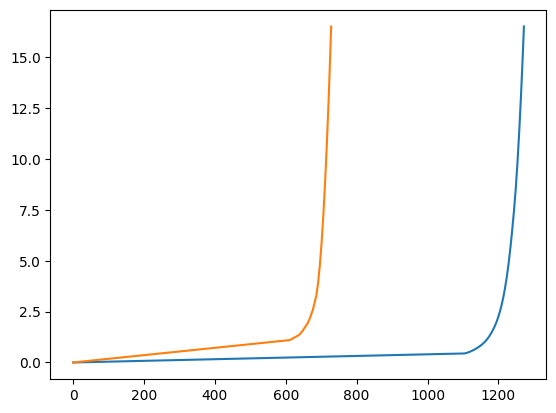

In [33]:
i0 = 0
for i in range(N-1):
    if (K[i]<S) & (S<K[i+1]):
        i0 = i
print(i0)

Lt1 = C[i0] + (S-K[i0])*(C[i0]-C[i0-1])/(K[i0]-K[i0-1])
Lt2 = C[i0+1] + (S-K[i0+1])*(C[i0+2]-C[i0+1])/(K[i0+2]-K[i0+1])
Lt = max([Lt1,Lt2])
print(Lt)

Ut = C[i0]*(K[i0+1]-S)/(K[i0+1]-K[i0]) + C[i0+1]*(S-K[i0])/(K[i0+1]-K[i0])
print(Ut)

delta = 0.5
Vtemp = delta*Lt + (1-delta)*Ut
print(Vtemp)

K1 = [0]
V1 = [0]
for i in range(N):
    if (K[i]<S):
        K1.append(K[i])
        V1.append(C[i]-S+K[i])

K2 = [0]
V2 = [0]
for i in range(N):
    if (K[N-1-i]>S):
        K2.append(Kbar - K[N-1-i])
        V2.append(C[N-1-i])
        
K1.append(S)
K2.append(Kbar-S)
V1.append(Vtemp)
V2.append(Vtemp)
plt.plot(K1,V1)
plt.plot(K2,V2)
print(K1)

In [63]:
def Interpolate(K,V):
    N = len(K)
    nu = []
    kappa = []
    omega = []
    sigmas = []
    A = V[0]
    delta = 0.5
    #B = delta*(V[1]-V[0])/(K[1]-K[0]) + (1-delta)*V[0]/K[0]
    B = delta*(V[1]-V[0])/(K[1]-K[0])
    for i in range(N-2):
        #print(i)
        K1t = K[i]
        K2t = K[i+1]
        V1t = V[i]
        V2t = V[i+1]
        B1 = delta*(V[i+2]-V2t)/(K[i+2]-K2t) + (1.0-delta)*(V2t-V1t)/(K2t-K1t)
        w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
        sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
        #print(sigma_h)
        sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
        #print(sigma)
        sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
        At = Atilde(sigma,A,B,w,K1t)
        Bt = Btilde(sigma,A,B,w,K1t)
        nu.append(K1t)
        nu.append(w)
        omega.append(1.0/sigma)
        omega.append(1.0/sigma_t)
        kappa.append([0.5*(A+sigma*B),0.5*(A-sigma*B)])
        kappa.append([0.5*(At+sigma_t*Bt),0.5*(At-sigma_t*Bt)])
        sigmas.append(sigma);
        sigmas.append(sigma_t);
        A = V2t
        #B = (0.5/sigma_t)*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) - (0.5/sigma_t)*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
        B=B1
    
    return nu, omega, kappa, B, sigmas

In [66]:
nu1, omega1, kappa1, B1_last, sigmas1 = Interpolate(K1,V1)
nu2, omega2, kappa2, B2_last, sigmas2 = Interpolate(K2,V2)
print(len(nu1))
print(len(sigmas1))

68
68


/var/folders/kw/428sj1x52c591vdwhxvprd880000gp/T/ipykernel_51944/4125427609.py:2: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)


# Final touch

In [14]:
delta1 = 0.5
rho = delta1 + delta1*(V2[-2]-V2[-1])/(K2[-1]-K2[-2]) + (1.0-delta1)*(V1[-1]-V1[-2])/(K1[-1]-K1[-2])
print(rho)
print(B1_last)
print(1-rho)
print(B2_last)

0.45292470081924047
0.4169322254512535
0.5470752991807595
0.5134484394379495


In [15]:
K1t = K1[-2]
K2t = K1[-1]
V1t = V1[-2]
V2t = V1[-1]
#print(K1t,K2t)
#print(V1t,V2t)
A = V1t
B = B1_last
B1 = rho
#print((V2t-V1t)/(K2t-K1t))
#print(B,B1)
w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
At = Atilde(sigma,A,B,w,K1t)
Bt = Btilde(sigma,A,B,w,K1t)

nu1.append(K1t)
nu1.append(w)
omega1.append(1.0/sigma)
omega1.append(1.0/sigma_t)
kappa1.append([0.5*(A+sigma*B),0.5*(A-sigma*B)])
kappa1.append([0.5*(At+sigma_t*Bt),0.5*(At-sigma_t*Bt)])

In [16]:
K1t = K2[-2]
K2t = K2[-1]
V1t = V2[-2]
V2t = V2[-1]
#print(K1t,K2t)
#print(V1t,V2t)
A = V1t
B = B2_last
B1 = 1 - rho
#print((V2t-V1t)/(K2t-K1t))
#print(B,B1)
w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
#print(sigma_h)
sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
#print(sigma)
sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
At = Atilde(sigma,A,B,w,K1t)
Bt = Btilde(sigma,A,B,w,K1t)

nu2.append(K1t)
nu2.append(w)
omega2.append(1.0/sigma)
omega2.append(1.0/sigma_t)
kappa2.append([0.5*(A+sigma*B),0.5*(A-sigma*B)])
kappa2.append([0.5*(At+sigma_t*Bt),0.5*(At-sigma_t*Bt)])

# Plot interpolated calls

In [17]:
def InterpolatedCalls(K,nu1,nu2,omega1,omega2,kappa1,kappa2):
    call = -1
    for i in range(len(nu1)-1):
        if (K>=nu1[i]) & (K<nu1[i+1]):
            call = S - K + kappa1[i][0]*np.exp(omega1[i]*(K-nu1[i])) + kappa1[i][1]*np.exp(-omega1[i]*(K-nu1[i]))
    for i in range(len(nu2)-1):
        if (Kbar-K>=nu2[i]) & (Kbar-K<nu2[i+1]):
            call = kappa2[i][0]*np.exp(omega2[i]*(Kbar-K-nu2[i])) + kappa2[i][1]*np.exp(-omega2[i]*(Kbar-K-nu2[i]))
    if (K>=nu1[-1]) & (K<S):
            call = S - K + kappa1[-1][0]*np.exp(omega1[-1]*(K-nu1[-1])) + kappa1[-1][1]*np.exp(-omega1[-1]*(K-nu1[-1]))
    if (Kbar-K>=nu2[-1]) & (K>=S):
            call = kappa2[-1][0]*np.exp(omega2[-1]*(Kbar-K-nu2[-1])) + kappa2[-1][1]*np.exp(-omega2[-1]*(Kbar-K-nu2[-1]))
    
    return call

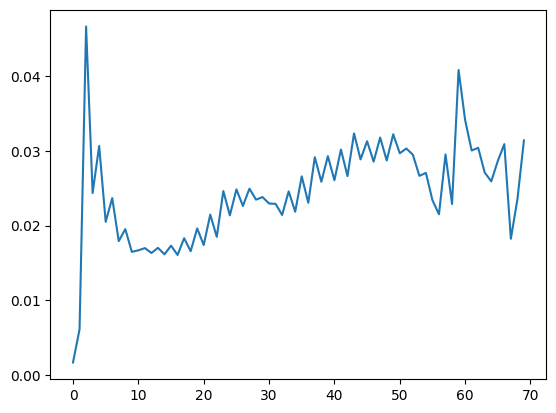

In [18]:
plt.plot(omega1)

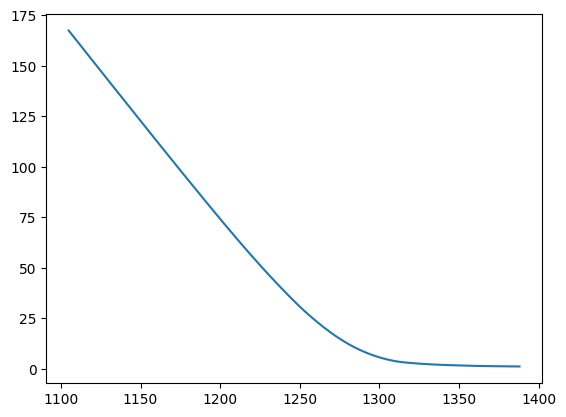

In [19]:
Kmin = min(K)
#Kmin = min(K1)
Kmax = max(K)
#Kmax = Kbar
K_plt = []
C_plt = []
Ktemp = Kmin
while (Ktemp<=Kmax-1):
    Ktemp=Ktemp+1
    K_plt.append(Ktemp)
    C_plt.append(InterpolatedCalls(K_plt[-1],nu1,nu2,omega1,omega2,kappa1,kappa2))
plt.plot(K_plt,C_plt)

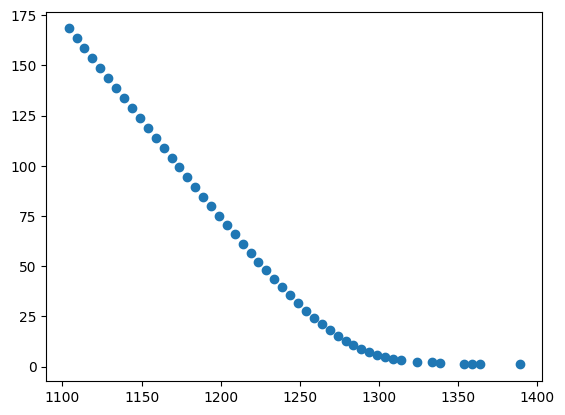

In [20]:
plt.scatter(K,C)

# Plot interpolated implied smile

In [21]:
def blackPremium(discountFactor, forward, strike, timeToExpiration, isCall, sigma):
    with np.errstate(divide = 'ignore'): # ignore warning: divide by zero
        terminalVolatility = sigma * np.sqrt(timeToExpiration)
        logMoneyness = np.log(np.divide(forward, strike))
        d1 = (0.0 if logMoneyness == 0.0 else np.divide(logMoneyness, terminalVolatility)) + 0.5 * terminalVolatility
        d2 = (0.0 if logMoneyness == 0.0 else np.divide(logMoneyness, terminalVolatility)) - 0.5 * terminalVolatility
        forwardCallPremium = forward * norm.cdf(d1) - strike * norm.cdf(d2)
        if isCall:
            return discountFactor * forwardCallPremium
        else:
            return discountFactor * (forwardCallPremium - (forward - strike))

In [22]:
def blackVolatility(discountFactor, forward, strike, timeToExpiration, isCall, premium):
    def getPremium(sigma):
        return blackPremium(discountFactor, forward, strike, timeToExpiration, isCall, sigma)
    if np.isnan(premium):
        return np.nan
    elif premium <= getPremium(0.0):
        return 0.0
    elif premium >= getPremium(np.inf):
        return np.inf
    low = 0.0
    high = 1.0
    while (getPremium(high) < premium):
        high = 2.0 * high
    while (high - low > 1.0e-8):
        mid = 0.5 * (low + high)
        if (getPremium(mid) >= premium):
            high = mid
        else:
            low = mid
    return 0.5 * (low + high)

In [23]:
C_h = []
C_l = []
data = []
with open('Quotes.csv', mode='r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            data.append(row)
            C_h.append(float(row[1]))
            C_l.append(float(row[2]))
print(len(K))
print(len(C_h))
#print(C_l)

50
50


In [24]:
T = 0.016
x = [np.log(k/S) for k in K_plt]
IV = [blackVolatility(1.0, S, K_plt[i], T, 'True', C_plt[i]) for i in range(len(x))]
x_mrkt = [np.log(k/S) for k in K]
IV_a = [blackVolatility(1.0, S, K[i], T, 'True', C_h[i]) for i in range(len(x_mrkt))]
IV_b = [blackVolatility(1.0, S, K[i], T, 'True', C_l[i]) for i in range(len(x_mrkt))]

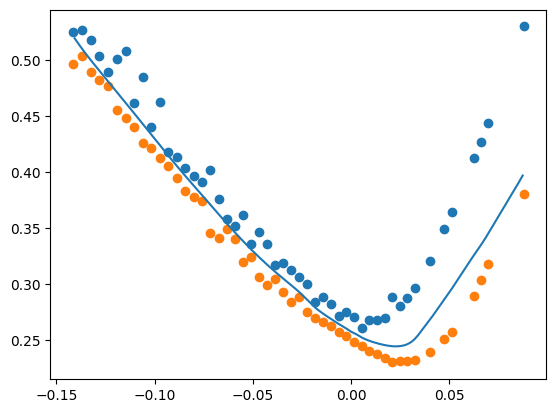

In [25]:
plt.plot(x,IV)
plt.scatter(x_mrkt,IV_a)
plt.scatter(x_mrkt,IV_b)

In [149]:
def recurse_c(c1_prev, c2_prev, sigma, sigma_prev, nu_prev):
    c1 = 0.5 * ((1+(sigma/sigma_prev)) * c1_prev * np.exp(-nu_prev/sigma_prev) + 
                (1-(sigma/sigma_prev)) * c2_prev * np.exp(nu_prev/sigma_prev)) / np.exp(-nu_prev/sigma)
    c2 = 0.5 * ((1-(sigma/sigma_prev)) * c1_prev * np.exp(-nu_prev/sigma_prev) + 
                (1+(sigma/sigma_prev)) * c2_prev * np.exp(nu_prev/sigma_prev)) / np.exp(nu_prev/sigma)
    return c1, c2

def generate_c(sigmas, nus):
    c1res = [0] * len(nus)
    c2res = [0] * len(nus)
    c1res[0] = -np.exp(nus[0]/sigmas[0])
    c2res[0] = np.exp(-nus[0]/sigmas[0])
    for i in range(1, len(nus)):
        c1res[i], c2res[i] = recurse_c(c1res[i-1], c2res[i-1], sigmas[i], sigmas[i-1], nus[i-1]);
    return c1res, c2res

def Dsigma_c(T, sigmas, nus, c1_list, c2_list):
    c1res = [0] * len(nus)
    c2res = [0] * len(nus)
    if T == 0: 
        c1res[0] = -np.exp(nus[0]/sigmas[0]) * -(nus[0]/(sigmas[0]**2))
        c2res[0] = np.exp(-nus[0]/sigmas[0]) * (nus[0]/(sigmas[0]**2))
    for i in range(T, len(nus)):
        if T == 0: continue
        if T == i:
            c1res[i] = ((0.5 * (((1/sigmas[i-1])*c1_list[i-1] + (1+sigmas[i]/sigmas[i-1])*c1res[i-1])*np.exp(-nus[i-1]/sigmas[i-1]) +
                              ((-1/sigmas[i-1])*c2_list[i-1] + (1-sigmas[i]/sigmas[i-1])*c2res[i-1])*np.exp(nus[i-1]/sigmas[i-1]))) 
                        / np.exp(-nus[i-1]/sigmas[i]) - c1_list[i] * (nus[i-1]/sigmas[i]**2))
            c2res[i] = ((0.5 * (((-1/sigmas[i-1])*c1_list[i-1] + (1-sigmas[i]/sigmas[i-1])*c1res[i-1])*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              ((1/sigmas[i-1])*c2_list[i-1] + (1+sigmas[i]/sigmas[i-1])*c2res[i-1])*np.exp(nus[i-1]/sigmas[i-1]))) 
                        / np.exp(nus[i-1]/sigmas[i]) - c2_list[i] * (-nus[i-1]/sigmas[i]**2))
        elif T == i - 1:
            c1res[i] = (0.5 * ((1+sigmas[i]/sigmas[i-1])*c1res[i-1]*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              (-sigmas[i]/sigmas[i-1]**2)*c1_list[i-1]*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              (1+sigmas[i]/sigmas[i-1])*c1_list[i-1]*np.exp(-nus[i-1]/sigmas[i-1])*(nus[i-1]/sigmas[i-1]**2) + 

                              (1-sigmas[i]/sigmas[i-1])*c2res[i-1]*np.exp(nus[i-1]/sigmas[i-1]) +
                              (sigmas[i]/sigmas[i-1]**2)*c2_list[i-1]*np.exp(nus[i-1]/sigmas[i-1]) + 
                              (1-sigmas[i]/sigmas[i-1])*c2_list[i-1]*np.exp(nus[i-1]/sigmas[i-1])*(-nus[i-1]/sigmas[i-1]**2))) / np.exp(-nus[i-1]/sigmas[i])

            c2res[i] = (0.5 * ((1-sigmas[i]/sigmas[i-1])*c1res[i-1]*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              (sigmas[i]/sigmas[i-1]**2)*c1_list[i-1]*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              (1-sigmas[i]/sigmas[i-1])*c1_list[i-1]*np.exp(-nus[i-1]/sigmas[i-1])*(nus[i-1]/sigmas[i-1]**2) + 

                              (1+sigmas[i]/sigmas[i-1])*c2res[i-1]*np.exp(nus[i-1]/sigmas[i-1]) +
                              (-sigmas[i]/sigmas[i-1]**2)*c2_list[i-1]*np.exp(nus[i-1]/sigmas[i-1]) + 
                              (1+sigmas[i]/sigmas[i-1])*c2_list[i-1]*np.exp(nus[i-1]/sigmas[i-1])*(-nus[i-1]/sigmas[i-1]**2))) / np.exp(nus[i-1]/sigmas[i])
                                   
        else:
            c1res[i] = (0.5 * ((1+sigmas[i]/sigmas[i-1])*np.exp(-nus[i-1]/sigmas[i-1])*c1res[i-1] + 
                              (1-sigmas[i]/sigmas[i-1])*np.exp(nus[i-1]/sigmas[i-1])*c2res[i-1])) / np.exp(-nus[i-1]/sigmas[i])
            c2res[i] = (0.5 * ((1-sigmas[i]/sigmas[i-1])*np.exp(-nus[i-1]/sigmas[i-1])*c1res[i-1] + 
                              (1+sigmas[i]/sigmas[i-1])*np.exp(nus[i-1]/sigmas[i-1])*c2res[i-1])) / np.exp(nus[i-1]/sigmas[i])
    return c1res, c2res

def Dnu_c(T, sigmas, nus, c1_list, c2_list):
    c1res = [0] * len(nus)
    c2res = [0] * len(nus)
    if T == 0: 
        c1res[0] = -np.exp(nus[0]/sigmas[0]) * (1/sigmas[0])
        c2res[0] = np.exp(-nus[0]/sigmas[0]) * (-1/sigmas[0])
    for i in range(T+1, len(nus)):
        if T == i - 1:
            c1res[i] = (0.5 * ((1+sigmas[i]/sigmas[i-1]*np.exp(-nus[i-1]/sigmas[i-1]))*(c1_list[i-1]*(-1/sigmas[i-1]) + c1res[i-1]) + 
                              (1-sigmas[i]/sigmas[i-1]*np.exp(nus[i-1]/sigmas[i-1]))*(c2_list[i-1]*(1/sigmas[i-1]) + c2res[i-1])) /
                        np.exp(-nus[i-1]/sigmas[i])) - c1_list[i]*(-1/sigmas[i])
            c2res[i] = (0.5 * ((1-sigmas[i]/sigmas[i-1]*np.exp(-nus[i-1]/sigmas[i-1]))*(c1_list[i-1]*(-1/sigmas[i-1]) + c1res[i-1]) + 
                              (1+sigmas[i]/sigmas[i-1]*np.exp(nus[i-1]/sigmas[i-1]))*(c2_list[i-1]*(1/sigmas[i-1]) + c2res[i-1])) /
                        np.exp(nus[i-1]/sigmas[i])) - c2_list[i]*(1/sigmas[i])
        else:
            c1res[i] = 0.5 * ((1+sigmas[i]/sigmas[i-1])*c1res[i-1]*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              (1-sigmas[i]/sigmas[i-1])*c2res[i-1]*np.exp(nus[i-1]/sigmas[i-1])) / np.exp(-nus[i-1]/sigmas[i])
            c2res[i] = 0.5 * ((1-sigmas[i]/sigmas[i-1])*c1res[i-1]*np.exp(-nus[i-1]/sigmas[i-1]) + 
                              (1+sigmas[i]/sigmas[i-1])*c2res[i-1]*np.exp(nus[i-1]/sigmas[i-1])) / np.exp(nus[i-1]/sigmas[i])
    return c1res, c2res

def Dsigma_V(K, Dc1, Dc2, c1_list, c2_list, sigmas, nus):
    result = []
    index = np.searchsorted(nus, K, side = 'right');
    for i in range(len(nus)):
        if (i == index): result.append(np.exp(-K/sigmas[index])*(Dc1[index][i] + c1_list[index]*(K / sigmas[index]**2)) + 
                                       np.exp(K/sigmas[index])*(Dc2[index][i] + c2_list[index]*(-K / sigmas[index]**2)))
        else: result.append(np.exp(-K/sigmas[index])*Dc1[index][i] + np.exp(K/sigmas[index])*Dc2[index][i])
    return result

def Dnu_V(K, Dc1, Dc2, c1_list, c2_list, sigmas, nus):
    result = []
    index = np.searchsorted(nus, K, side = 'right');
    for i in range(len(nus)):
        result.append(np.exp(-K/sigmas[index])*Dc1[index][i] + np.exp(K/sigmas[index])*Dc2[index][i])
    return result
    
def V(K, c1_list, c2_list, sigmas, nus):
    index = np.searchsorted(nus, K, side = 'right');
    c1 = np.asarray(c1_list)
    c2 = np.asarray(c2_list)
    s = np.asarray(sigmas)
    return c1[index] * np.exp(-K / s[index]) + c2[index] * np.exp(K / s[index])

# the func below was vibe coded

def generate_Dc(sigmas, nus, c1_list, c2_list):
    N = len(nus)
    
    # Temporary lists to hold rows grouped by parameter i
    temp_Dsigma_c1 = []
    temp_Dsigma_c2 = []
    temp_Dnu_c1 = []
    temp_Dnu_c2 = []
    
    # Loop through each parameter index i
    for i in range(N):
        # Calculate partials w.r.t sigma_i
        ds_c1, ds_c2 = Dsigma_c(i, sigmas, nus, c1_list, c2_list)
        temp_Dsigma_c1.append(ds_c1)
        temp_Dsigma_c2.append(ds_c2)
        
        # Calculate partials w.r.t nu_i
        dn_c1, dn_c2 = Dnu_c(i, sigmas, nus, c1_list, c2_list)
        temp_Dnu_c1.append(dn_c1)
        temp_Dnu_c2.append(dn_c2)
        
    # Transpose the matrices so they are grouped by c term (j) first, then parameter (i)
    # The resulting shape will be (N, N) where matrix[j][i] = d(c_j) / d(param_i)
    Dc1_sigma = np.array(temp_Dsigma_c1).T.tolist()
    Dc2_sigma = np.array(temp_Dsigma_c2).T.tolist()
    
    Dc1_nu = np.array(temp_Dnu_c1).T.tolist()
    Dc2_nu = np.array(temp_Dnu_c2).T.tolist()
    
    return Dc1_sigma, Dc2_sigma, Dc1_nu, Dc2_nu


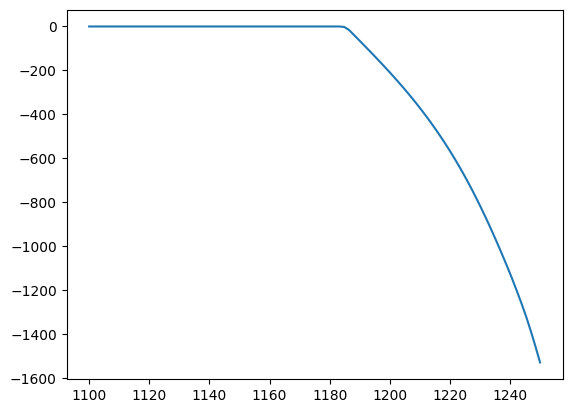

In [158]:
c1_list, c2_list = generate_c(sigmas1, nu1)

Dc1_sigma, Dc2_sigma, Dc1_nu, Dc2_nu = generate_Dc(sigmas1, nu1, c1_list, c2_list)

x = np.linspace(1100, 1250, 100)
y_all_parameters = [Dsigma_V(k, Dc1_sigma, Dc2_sigma, c1_list, c2_list, sigmas1, nu1) for k in x]
y = [result[35] for result in y_all_parameters]

plt.plot(x, y)
plt.show()